# Notebook 01 _ Audit des données

## Objectif

Ce notebook constitue la première étape du projet de fin d'études.

Son objectif est d'évaluer la qualité des données avant toute étape de nettoyage ou de modélisation.

Les tâches réalisées sont :

- Importation des bibliothèques
- Chargement des données
- Inspection du dataset
- Audit des données
- Analyse exploratoire
- Corrélations
- Conclusion

In [1]:
# IMPORTATION DES BIBLIOTHÈQUES

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Configuration graphique
plt.style.use("ggplot")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

print("Les bibliothèques sont importées avec succès")

Les bibliothèques sont importées avec succès


In [2]:
# CHEMINS DU PROJET

PROJECT_DIR = Path.cwd().parent

DATA_DIR = PROJECT_DIR / "data"

RAW_DATA_DIR = DATA_DIR / "raw"

FIGURES_DIR = PROJECT_DIR / "figures"

print("Projet :", PROJECT_DIR)
print("Données :", RAW_DATA_DIR)

Projet : c:\Users\celes\Desktop\PFE
Données : c:\Users\celes\Desktop\PFE\data\raw


In [3]:
# CHARGEMENT DES JEUX DE DONNÉES

# Dataset énergétique
energy_df = pd.read_csv(
    RAW_DATA_DIR / "Database.csv"
)

# Dataset NASA POWER
nasa_file = RAW_DATA_DIR / "NASA_POWER_Fes_1990_2025.csv"

with open(nasa_file, "r", encoding="utf-8") as file:
    lines = file.readlines()

end_header_index = next(
    index
    for index, line in enumerate(lines)
    if "-END HEADER-" in line
)

nasa_df = pd.read_csv(
    nasa_file,
    skiprows=end_header_index + 1
)

# Données européennes de production
opsd_df = pd.read_csv(
    RAW_DATA_DIR / "time_series_60min_singleindex.csv"
)

# Données météorologiques européennes
weather_df = pd.read_csv(
    RAW_DATA_DIR / "weather_data.csv"
)

print(" Les quatre jeux de données ont été chargés.")

 Les quatre jeux de données ont été chargés.


In [4]:
# DIMENSIONS DES JEUX DE DONNÉES

datasets_summary = pd.DataFrame({
    "Dataset": [
        "Energy",
        "NASA POWER",
        "Open Power System Data",
        "Weather"
    ],
    "Nombre de lignes": [
        energy_df.shape[0],
        nasa_df.shape[0],
        opsd_df.shape[0],
        weather_df.shape[0]
    ],
    "Nombre de colonnes": [
        energy_df.shape[1],
        nasa_df.shape[1],
        opsd_df.shape[1],
        weather_df.shape[1]
    ]
})

datasets_summary

,Dataset,Nombre de lignes,Nombre de colonnes
0,Energy,315648,13
1,NASA POWER,13149,7
2,Open Power System Data,50401,300
3,Weather,350640,85


### Interprétation

Les quatre jeux de données ont été chargés.

Le jeu de données **Energy** sera utilisé comme base principale pour le développement des modèles d'intelligence artificielle.

Le jeu de données **NASA POWER** permettra d'étudier l'évolution des variables climatiques sur une longue période.

Les données **Open Power System Data** seront utilisées pour comparer les résultats sur des données européennes réelles.

Enfin, le jeu de données **Weather** apportera des variables météorologiques complémentaires à l'analyse.

In [5]:
# APERÇU DU DATASET ENERGY

energy_df.head()

,Unnamed: 0,Time,Season,Day_of_the_week,DHI,DNI,GHI,Wind_speed,Humidity,Temperature,PV_production,Wind_production,Electric_demand
0,0,2019-01-01-T00:00,1,1,0.0,0.0,0.0,2.88,56.036,1.82,0,2810,22216
1,1,2019-01-01-T00:05,1,1,0.0,0.0,0.0,2.88,56.036,1.82,0,2862,22106
2,2,2019-01-01-T00:10,1,1,0.0,0.0,0.0,2.88,56.194,1.78,0,2916,22130
3,3,2019-01-01-T00:15,1,1,0.0,0.0,0.0,2.88,56.344,1.74,0,2920,22040
4,4,2019-01-01-T00:20,1,1,0.0,0.0,0.0,2.84,56.440,1.72,0,2902,21963


In [6]:
# INFORMATIONS GÉNÉRALES

energy_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 315648 entries, 0 to 315647
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Unnamed: 0       315648 non-null  int64  
 1   Time             315648 non-null  str    
 2   Season           315648 non-null  int64  
 3   Day_of_the_week  315648 non-null  int64  
 4   DHI              315648 non-null  float64
 5   DNI              315648 non-null  float64
 6   GHI              315648 non-null  float64
 7   Wind_speed       315648 non-null  float64
 8   Humidity         315648 non-null  float64
 9   Temperature      315648 non-null  float64
 10  PV_production    315648 non-null  int64  
 11  Wind_production  315648 non-null  int64  
 12  Electric_demand  315648 non-null  int64  
dtypes: float64(6), int64(6), str(1)
memory usage: 36.4 MB


In [7]:
# STATISTIQUES DESCRIPTIVES

energy_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,315648.0,NaN,NaN,NaN,157823.5,91119.873222,0.0,78911.75,157823.5,236735.25,315647.0
Time,315648,315648,2019-01-01-T00:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,315648.0,NaN,NaN,NaN,2.508212,1.117189,1.0,2.0,3.0,4.0,4.0
Day_of_the_week,315648.0,NaN,NaN,NaN,2.998175,1.99772,0.0,1.0,3.0,5.0,6.0
DHI,315648.0,NaN,NaN,NaN,53.779907,68.829995,0.0,0.0,7.6,98.8,431.0
DNI,315648.0,NaN,NaN,NaN,288.058615,336.05704,0.0,0.0,38.0,601.6,999.8
GHI,315648.0,NaN,NaN,NaN,221.787985,296.632914,0.0,0.0,10.2,427.2,1058.2
Wind_speed,315648.0,NaN,NaN,NaN,2.545759,1.042771,0.66,1.76,2.34,3.16,8.54
Humidity,315648.0,NaN,NaN,NaN,51.261462,16.319826,11.572,38.38,51.662,63.644,88.688
Temperature,315648.0,NaN,NaN,NaN,17.472179,7.701694,-0.54,11.2,16.7,22.8,39.02


In [8]:
# AUDIT DU DATASET ENERGY

energy_audit = pd.DataFrame({
    "Variable": energy_df.columns,
    "Type": energy_df.dtypes.astype(str).values,
    "Valeurs manquantes": energy_df.isnull().sum().values,
    "Valeurs uniques": energy_df.nunique().values
})

energy_audit

,Variable,Type,Valeurs manquantes,Valeurs uniques
0,Unnamed: 0,int64,0,315648
1,Time,str,0,315648
2,Season,int64,0,4
3,Day_of_the_week,int64,0,7
4,DHI,float64,0,1892
5,DNI,float64,0,4955
6,GHI,float64,0,5240
7,Wind_speed,float64,0,831
8,Humidity,float64,0,54521
9,Temperature,float64,0,3992


In [9]:
# RECHERCHE DE DOUBLONS

duplicate_count = energy_df.duplicated().sum()

print(f"Nombre de doublons : {duplicate_count}")

Nombre de doublons : 0


In [10]:
# VALEURS MANQUANTES

missing_values = pd.DataFrame({
    "Valeurs manquantes": energy_df.isnull().sum(),
    "Pourcentage (%)": (
        energy_df.isnull().mean()*100
    ).round(2)
})

missing_values

,Valeurs manquantes,Pourcentage (%)
Unnamed: 0,0,0.0
Time,0,0.0
Season,0,0.0
Day_of_the_week,0,0.0
DHI,0,0.0
DNI,0,0.0
GHI,0,0.0
Wind_speed,0,0.0
Humidity,0,0.0
Temperature,0,0.0


### Analyse des doublons

Cette vérification permet d'identifier la présence éventuelle de lignes dupliquées et de valeurs manquantes.

Leurs présences pourraient introduire un biais lors de l'entraînement des modèles d'intelligence artificielle.

Les résultats obtenus seront utilisés pour déterminer si un nettoyage est nécessaire.

In [11]:
# TYPES DES VARIABLES

audit_df = pd.DataFrame({
    "Variable": energy_df.columns,
    "Type": energy_df.dtypes.astype(str).values,
    "Valeurs uniques": energy_df.nunique().values
})

audit_df

,Variable,Type,Valeurs uniques
0,Unnamed: 0,int64,315648
1,Time,str,315648
2,Season,int64,4
3,Day_of_the_week,int64,7
4,DHI,float64,1892
5,DNI,float64,4955
6,GHI,float64,5240
7,Wind_speed,float64,831
8,Humidity,float64,54521
9,Temperature,float64,3992


In [12]:
# CONVERSION DE LA DATE

energy_df["Time"] = pd.to_datetime(energy_df["Time"])

print(energy_df["Time"].dtype)

datetime64[us]


In [13]:
energy_df["Time"].head()

0   2019-01-01 00:00:00
1   2019-01-01 00:05:00
2   2019-01-01 00:10:00
3   2019-01-01 00:15:00
4   2019-01-01 00:20:00
Name: Time, dtype: datetime64[us]

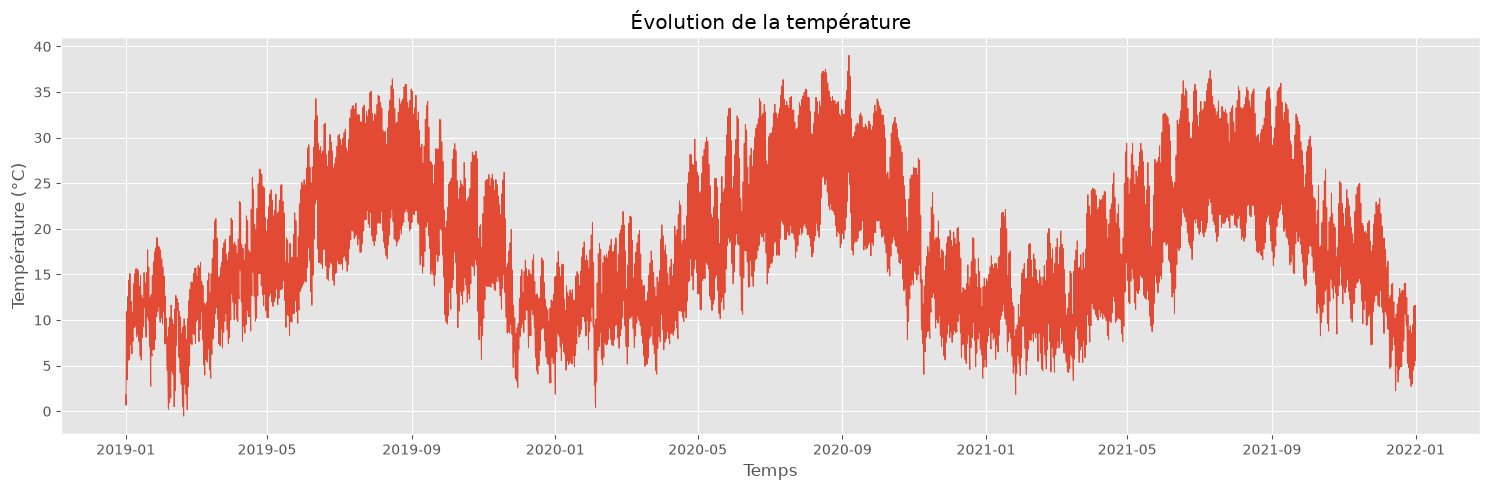

In [14]:
# ÉVOLUTION DE LA TEMPÉRATURE

plt.figure(figsize=(15,5))

plt.plot(
    energy_df["Time"],
    energy_df["Temperature"],
    linewidth=0.7
)

plt.title("Évolution de la température")

plt.xlabel("Temps")

plt.ylabel("Température (°C)")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "evolution_temperature.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interprétation

La figure présente l'évolution de la température entre 2019 et 2021.

On observe une variation saisonnière très marquée, caractérisée par des températures élevées durant les mois d'été et des températures plus faibles durant l'hiver.

Cette évolution est cohérente avec les cycles climatiques attendus et confirme la qualité du jeu de données utilisé.

Aucune anomalie majeure ou rupture brutale n'est observée, ce qui constitue un premier indicateur de fiabilité des mesures.

## Audit rapide des autres jeux de données

In [15]:
datasets = {
    "NASA": nasa_df,
    "OPSD": opsd_df,
    "Weather": weather_df
}

for name, df in datasets.items():
    print("=" * 50)
    print(name)
    print("=" * 50)
    print("Dimensions :", df.shape)
    print("Valeurs manquantes :", df.isnull().sum().sum())
    print("Doublons :", df.duplicated().sum())
    print()

NASA
Dimensions : (13149, 7)
Valeurs manquantes : 0
Doublons : 0

OPSD
Dimensions : (50401, 300)
Valeurs manquantes : 1333095
Doublons : 0

Weather
Dimensions : (350640, 85)
Valeurs manquantes : 0
Doublons : 0



### PETITE NOTTE


Les trois jeux de données complémentaires ont été inspectés afin de vérifier leur intégrité. Une analyse exploratoire détaillée est réalisée uniquement sur le jeu de données **Energy**, puisqu'il constitue le jeu principal utilisé pour les étapes de fusion, de prétraitement et de modélisation.

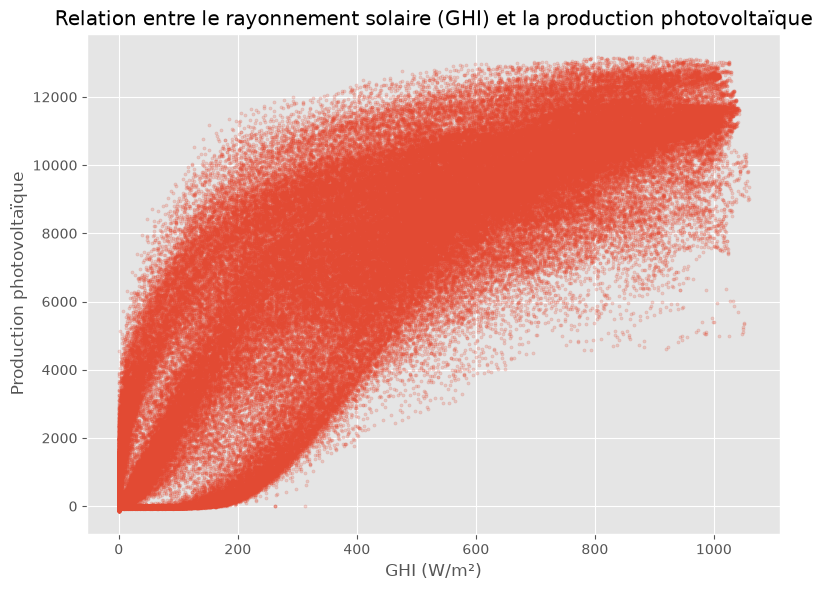

In [16]:
# RELATION ENTRE GHI ET PRODUCTION PHOTOVOLTAÏQUE

plt.figure(figsize=(8,6))

plt.scatter(
    energy_df["GHI"],
    energy_df["PV_production"],
    alpha=0.2,
    s=5
)

plt.title("Relation entre le rayonnement solaire (GHI) et la production photovoltaïque")

plt.xlabel("GHI (W/m²)")

plt.ylabel("Production photovoltaïque")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "relation_entre_raysolaire_productionphotovolt.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
# CORRÉLATION

correlation = energy_df["GHI"].corr(
    energy_df["PV_production"]
)

print(f"Corrélation : {correlation:.3f}")

Corrélation : 0.915


### Interprétation

La figure met en évidence une relation positive très marquée entre le rayonnement solaire global (GHI) et la production photovoltaïque.

Le coefficient de corrélation de Pearson obtenu est égal à **0,915**, ce qui traduit une très forte dépendance entre ces deux variables.

Ce résultat confirme que le rayonnement solaire constitue l'un des principaux facteurs explicatifs de la production d'énergie photovoltaïque.

Cette observation justifie pleinement l'utilisation des variables climatiques comme variables d'entrée des modèles d'intelligence artificielle développés dans ce projet.

In [18]:
# SÉLECTION DES VARIABLES NUMÉRIQUES

correlation_df = energy_df[
    [
        "DHI",
        "DNI",
        "GHI",
        "Wind_speed",
        "Humidity",
        "Temperature",
        "PV_production",
        "Wind_production",
        "Electric_demand"
    ]
]

correlation_df.head()

,DHI,DNI,GHI,Wind_speed,Humidity,Temperature,PV_production,Wind_production,Electric_demand
0,0.0,0.0,0.0,2.88,56.036,1.82,0,2810,22216
1,0.0,0.0,0.0,2.88,56.036,1.82,0,2862,22106
2,0.0,0.0,0.0,2.88,56.194,1.78,0,2916,22130
3,0.0,0.0,0.0,2.88,56.344,1.74,0,2920,22040
4,0.0,0.0,0.0,2.84,56.440,1.72,0,2902,21963


In [19]:
# MATRICE DE CORRÉLATION

corr_matrix = correlation_df.corr()

corr_matrix

,DHI,DNI,GHI,Wind_speed,Humidity,Temperature,PV_production,Wind_production,Electric_demand
DHI,1.000000,0.751256,0.858813,0.533452,-0.547314,0.538361,0.831700,-0.149654,0.056748
DNI,0.751256,1.000000,0.915774,0.471966,-0.683504,0.573619,0.905016,-0.199340,0.034144
GHI,0.858813,0.915774,1.000000,0.506684,-0.666686,0.624181,0.915301,-0.187742,0.043231
Wind_speed,0.533452,0.471966,0.506684,1.000000,-0.211321,0.187664,0.530953,0.246214,0.039932
Humidity,-0.547314,-0.683504,-0.666686,-0.211321,1.000000,-0.775161,-0.690560,0.262068,-0.364939
Temperature,0.538361,0.573619,0.624181,0.187664,-0.775161,1.000000,0.624932,-0.062259,0.550703
PV_production,0.831700,0.905016,0.915301,0.530953,-0.690560,0.624932,1.000000,-0.161370,0.127057
Wind_production,-0.149654,-0.199340,-0.187742,0.246214,0.262068,-0.062259,-0.161370,1.000000,0.010512
Electric_demand,0.056748,0.034144,0.043231,0.039932,-0.364939,0.550703,0.127057,0.010512,1.000000


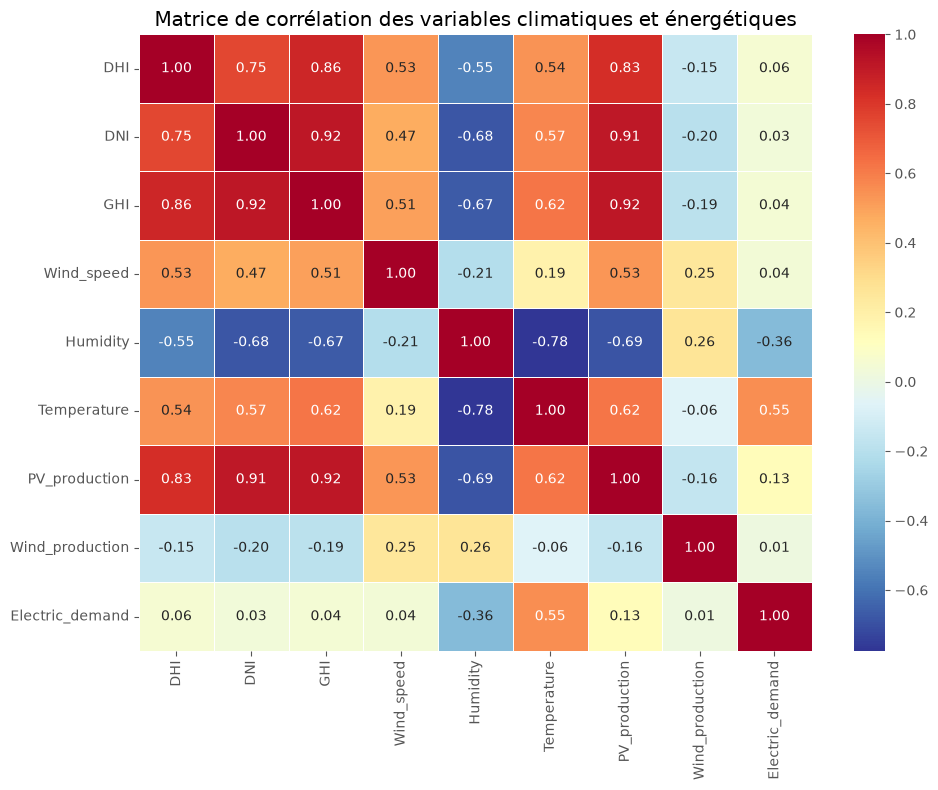

In [20]:
# HEATMAP DES CORRÉLATIONS

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdYlBu_r",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matrice de corrélation des variables climatiques et énergétiques")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "matrice_correlation_var_climatiques_energetiques.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Analyse de la matrice de corrélation

Cette matrice permet d'étudier les relations linéaires entre les variables climatiques et les variables énergétiques.

Les coefficients de corrélation les plus élevés indiquent les variables susceptibles d'avoir la plus grande influence sur la production énergétique.

Cette analyse constitue une première étape dans la sélection des variables utilisées pour entraîner les modèles d'intelligence artificielle.

# Distribution des variables

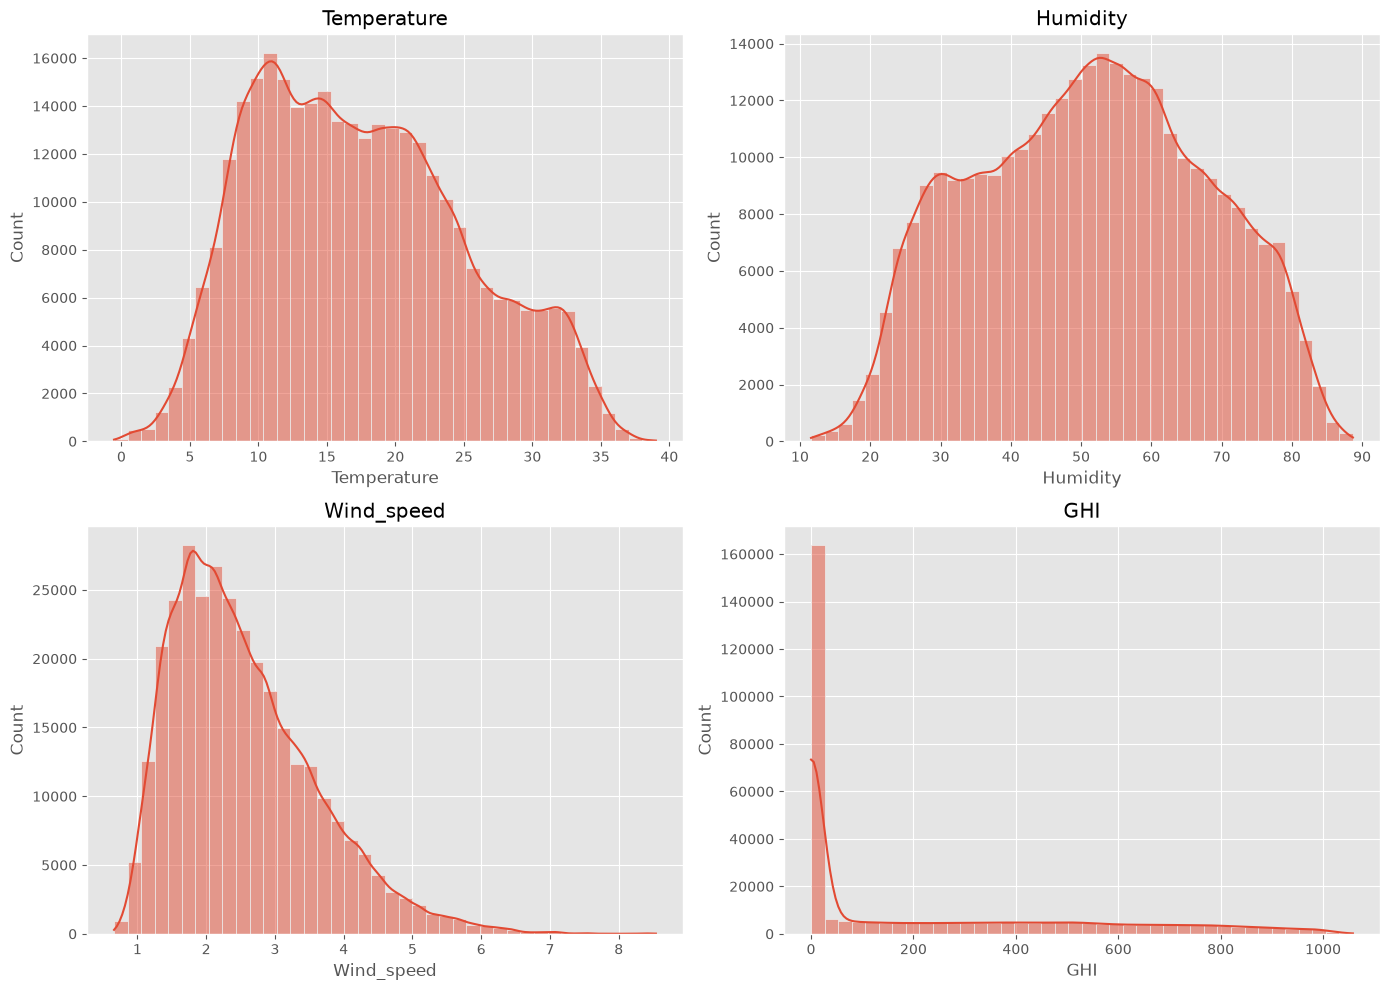

In [21]:
# DISTRIBUTION DES VARIABLES CLIMATIQUES

variables = [
    "Temperature",
    "Humidity",
    "Wind_speed",
    "GHI"
]

plt.figure(figsize=(14,10))

for i, variable in enumerate(variables, 1):

    plt.subplot(2,2,i)

    sns.histplot(
        energy_df[variable],
        bins=40,
        kde=True
    )

    plt.title(variable)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "distribution_variables.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Analyse des distributions

Les histogrammes mettent en évidence des distributions cohérentes avec les phénomènes climatiques observés.

- La température présente plusieurs pics correspondant aux différentes saisons.
- L'humidité est majoritairement comprise entre 40 % et 70 %.
- La vitesse du vent présente une distribution asymétrique avec une majorité de faibles vitesses.
- Le rayonnement solaire (GHI) comporte un grand nombre de valeurs proches de zéro, correspondant aux périodes nocturnes.

Ces observations confirment la qualité et la cohérence physique du jeu de données avant les étapes de modélisation.

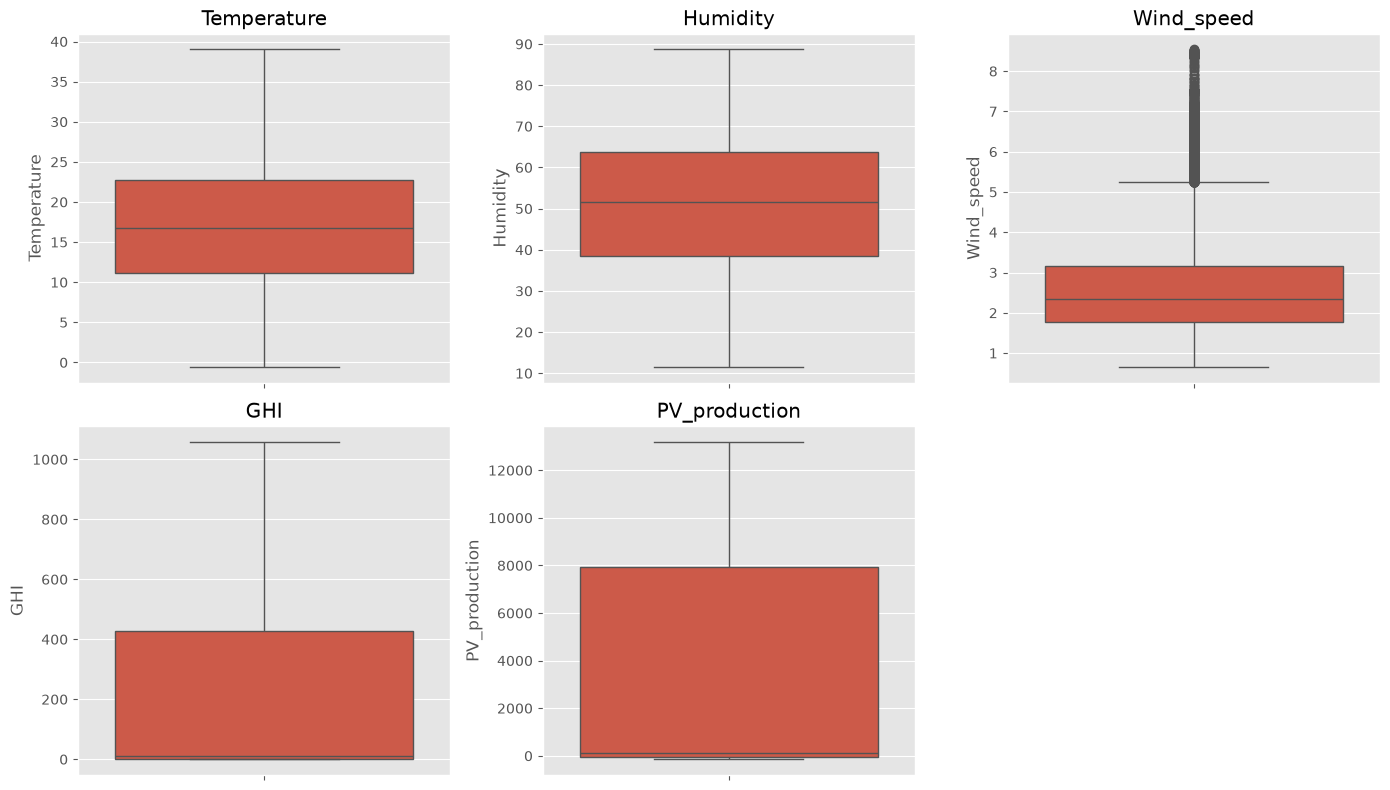

In [22]:
# DÉTECTION DES VALEURS ABERRANTES

variables = [
    "Temperature",
    "Humidity",
    "Wind_speed",
    "GHI",
    "PV_production"
]

plt.figure(figsize=(14,8))

for i, variable in enumerate(variables, 1):

    plt.subplot(2,3,i)

    sns.boxplot(
        y=energy_df[variable]
    )

    plt.title(variable)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "boxplots_variables.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
# RÉSUMÉ DE L'AUDIT

print("="*60)
print("Résumé DU NOTEBOOK 01")
print("="*60)

print(f"Nombre d'observations : {energy_df.shape[0]}")
print(f"Nombre de variables : {energy_df.shape[1]}")
print(f"Valeurs manquantes : {energy_df.isnull().sum().sum()}")
print(f"Doublons : {energy_df.duplicated().sum()}")

print("="*60)

Résumé DU NOTEBOOK 01
Nombre d'observations : 315648
Nombre de variables : 13
Valeurs manquantes : 0
Doublons : 0


# Conclusions du Notebook 01

## Objectif

L'objectif de ce notebook était de réaliser un audit complet du jeu de données principal afin d'évaluer sa qualité avant toute étape de modélisation.

## Résultats obtenus

- Les données ont été chargées avec succès.
- La structure du dataset a été vérifiée.
- Aucun doublon n'a été détecté.
- Aucune valeur manquante n'a été observée.
- Les variables temporelles ont été converties au bon format.
- Les premières analyses exploratoires ont confirmé la cohérence des données.
- Une forte corrélation (0,915) a été observée entre le rayonnement solaire (GHI) et la production photovoltaïque.
- Les distributions des principales variables climatiques ont été étudiées.

## Conclusion

Le jeu de données présente une qualité suffisante pour être utilisé dans les prochaines étapes du projet.

Le notebook suivant sera consacré au nettoyage et à la préparation des données avant l'entraînement des modèles d'intelligence artificielle.